# Part 1: Recognition

In this part of the assignment, you will implement and train neural networks, including convolutional neural networks, for an image recognition task using PyTorch. Specifically, we will classify color images of animals, vehicles, and other objects by predicting a label for the object type.

**Learning objectives.** You will:
1. Define multilayer perceptrons and convolutional neural networks using PyTorch
2. Optimize neural networks using automatic differentation and minibatch stochastic gradient descent in PyTorch
3. Evaluate different learning hyperparameters and model architecture choices by evaluating validation performance
4. Accelerate neural network training and inference using a graphics processing unit (GPU) with software support in PyTorch

## Getting Started

We recommend that you start by reviewing the extremely concise [PyTorch Quickstart tutorial](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html), which will help familiarize you with the API and the tasks below. You can also review more specific concepts in more detail beyond the quickstart -- there are additional tutorial pages with more details on tensors, Datasets and Dataloaders, etc.

Once you are ready to get started experimenting yourself, run the following code to import relevant PyTorch modules, download the dataset, split into a train, validation, and test dataset, and prepare PyTorch dataloaders for batching.

In [3]:
# Run but DO NOT MODIFY this code

# Import libraries
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

# Set a random seed for reproducibility
torch.manual_seed(2025)

# Load CIFAR-10 dataset
train_data = datasets.CIFAR10(root="data", train=True, download=True, transform=ToTensor())
train_set, val_set = random_split(train_data, [0.8, 0.2])
test_data = datasets.CIFAR10(root="data", train=False, download=True, transform=ToTensor())

# Prepare DataLoaders
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:03<00:00, 46.6MB/s] 


Then run the following code to visualize some random examples of the training data. You will see that you are working with color images of objects belonging to one of ten labeled classes. Our goal will be to build predictive models that take an image as input and predict the class to which they belong (e.g., is this an image of a cat or a truck?)

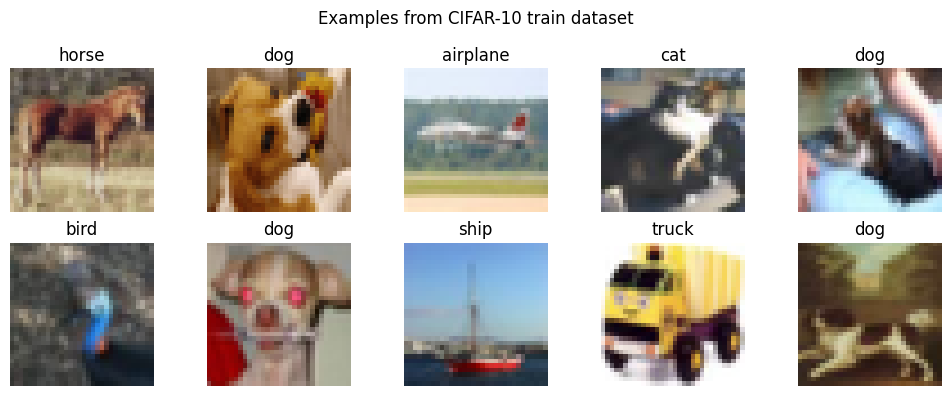

In [4]:
# Run but DO NOT MODIFY this code

# Visualize Random Examples
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog",
           "horse", "ship", "truck"]

# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# Get some random training images
dataiter = iter(torch.utils.data.DataLoader(train_data, batch_size=10, shuffle=True))
images, labels = next(dataiter)

# Create a grid of subplots
fig, axs = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle('Examples from CIFAR-10 train dataset', fontsize=12)

# Plot 10 images
for i, ax in enumerate(axs.flat):
    ax.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
    ax.set_title(f"{classes[labels[i]]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

Run the following code to define a helper function for visualizing your model training and validation performance.

In [5]:
# Run but DO NOT MODIFY this code

from matplotlib import pyplot as plt

# Helper function to visualize performance during training
def plot_training_curves(train_losses, val_accuracies):
    """Plot training loss and validation accuracy curves.
    
    Parameters
    ----------
    train_losses : list of float
        Training loss values for each epoch. Should have one value per epoch.
    val_accuracies : list of float
        Validation accuracy values for each epoch. Should have same length as
        train_losses. Accuracy values should be between 0 and 1 (or 0 and 100
        if using percentages).
        
    Returns
    -------
    None
        Displays matplotlib figure with two subplots showing training curves.
        
    Examples
    --------
    >>> train_losses = [0.8, 0.6, 0.4, 0.3, 0.2]
    >>> val_accuracies = [0.75, 0.80, 0.85, 0.87, 0.88]
    >>> plot_training_curves(train_losses, val_accuracies)
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train_losses)
    ax1.set_title('Training Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.grid(True)
    
    ax2.plot(val_accuracies)
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

## Task 1

In this task you will build and train an MLP classifier using PyTorch and CPU compute.

**1. Define a multilayer perceptron [using PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)** to classify the CIFAR-10 images. Your architecture should:
  - [Flatten](https://docs.pytorch.org/docs/stable/generated/torch.flatten.html) the 32×32×3 input images to vectors of size 3072
  - Contain at least two [linear layers](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) (i.e., at least one hidden layer plus one output layer). The basic structure is: **input → hidden → output**. You may use a deeper model with additional hidden layers (like two hidden layers + one output layer), but this is not required. 
  - Use nonlinear activations ([ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) recommended) for hidden layers
  - Have 10 output units for the classification task
  - Use no more than 10,000,000 total model parameters. You will likely want to use hidden layers with hundreds or even thousands of hidden units for this larger input size.

**2. Train your model** to minimize the [Cross entropy loss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) on the training data. For this task simply use the CPU for training (this is the default and does not require you to do anything). For training, you should:
  - Use the [SGD optimizer](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) that implements standard minibatch stochastic gradient descent, or the [Adam optimizer](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html). You may need to adjust hyperparameters (e.g., for the learning rate, momentum, etc.) but can start with the default values.
  - Evaluate and record the training loss and validation accuracy once per epoch so that you can visualize training performance using the `plot_training_curves` function defined above.
  - Implement early stopping so that your model stops training if the validation accuracy does not improve for a few consecutive epochs (a concept known as 'patience'). While you can set the patience value to 1 (stop after the first epoch with no improvement), you might get better results with a patience of 2 or 3 to avoid stopping prematurely due to minor fluctuations. You may also want to set a maximum number of epochs (e.g., 10 or 20) to ensure that the code terminates in a reasonable amount of time even if training hyperparameters are suboptimal.
  - Record the total amount of time (in seconds) to train the model and the average time per epoch (you will be asked to use the average time per epoch again later in task 2 for a fair comparison). You can use Python's [`time()` functionality](https://docs.python.org/3/library/time.html#time.time).
  - Note that the `train_loader` and `val_loader` defined above can be used for automatic batching and shuffling the training and validation data during training. 
  - Note that the `test_loader` should not be used in this task.
    
**Your goal is to achieve a validation accuracy of 45% or better using no more than 10,000,000 total model parameters.** Note that there are ten classes so random guessing with balanced data would only achieve 10% accuracy in expectation.

Once you reach this goal, **report the following:**
  - Use the `plot_training_curves` function to visualize the training results
  - Report the total number of model parameters. Show your work for the number of model parameters, either by showing your calculations or showing the code you used to count the number of model parameters ([The .parameters() method will return an iterable over the model parameters](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.parameters)).
  - Report the total amount of time that was required to train your model in seconds.
  - Report the average time per epoch in seconds.

Epoch 1 | Train Loss: 2.0580 | Val Acc: 30.56%
Epoch 2 | Train Loss: 1.9327 | Val Acc: 28.97%
Epoch 3 | Train Loss: 1.9480 | Val Acc: 28.06%
Epoch 4 | Train Loss: 1.9361 | Val Acc: 28.16%


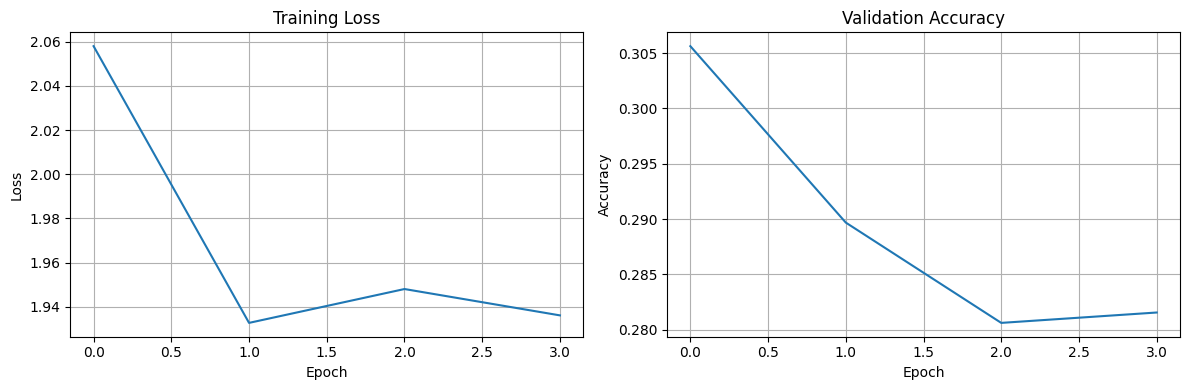

Total Parameters: 1,707,274
Total Training Time (s): 16.92
Average Time per Epoch (s): 4.23
Best Validation Accuracy (%): 30.56


In [6]:
import torch
import torch.nn as nn
import time

torch.manual_seed(2025)

class MLP(nn.Module):
    def __init__(self, h1=512, h2=256):
        super().__init__()
        self.fc1 = nn.Linear(3072, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def val_acc(model, loader, max_batches=50):
    model.eval()
    correct = total = 0
    for i, (x, y) in enumerate(loader):
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.numel()
        if i + 1 >= max_batches:
            break
    return correct / total

def train_task1(train_loader, val_loader,
                max_epochs=20,
                patience=3,
                lr=0.05,
                max_batches_per_epoch=200):

    model = MLP()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_accs = []
    epoch_times = []

    best_acc = -1.0
    best_state = None
    bad_epochs = 0

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        model.train()

        total_loss = 0.0
        total_samples = 0

        for batch_idx, (x, y) in enumerate(train_loader, start=1):
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            if batch_idx >= max_batches_per_epoch:
                break

        train_loss = total_loss / total_samples
        acc = val_acc(model, val_loader)

        train_losses.append(train_loss)
        val_accs.append(acc)
        epoch_times.append(time.time() - epoch_start)

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_accs, total_time, avg_epoch_time


model, train_losses, val_accs, total_time, avg_epoch_time = train_task1(
    train_loader,
    val_loader
)

plot_training_curves(train_losses, val_accs)

print(f"Total Parameters: {count_params(model):,}")
print(f"Total Training Time (s): {total_time:.2f}")
print(f"Average Time per Epoch (s): {avg_epoch_time:.2f}")
print(f"Best Validation Accuracy (%): {max(val_accs)*100:.2f}")


*For Task 1: report the number of model parameters, show work, total training time, and average time per epoch here*

| Metric | Value |
|--------|-------|
| **Total Parameters** | 1,707,274|
| **Work/Code Used** |Layer 1 (3072 → 512): 3072 × 512 + 512 = 1,573,376, Layer 2 (512 → 256): 512 × 256 + 256 = 131,328, Output Layer (256 → 10) : 256 × 10 + 10 = 2,570 Total: 1,573,376 + 131,328 + 2,570 = 1,707,274|
| **Total Training Time (seconds)** | 22.28|
| **Average Time per Epoch (seconds)** |5.57 |

## Task 2

Train the **exact same** multilayer perceptron architecture that you defined in Task 1, exactly as you trained it in Task 1, but this time **use GPU compute to accelerate the training.** A GPU is a Graphics Processing Unit and is specialized to efficiently compute intensive but highly parallel operations such as matrix multiplications.

If you are running this code on the Google Colab or a CS Department Compute Cluster OnDemand, you should have access to a CUDA enabled GPU device. In both cases you will need to specifically request a GPU. Using OnDemand, you should request a device from gpu partition and request 1 GPU. To change the Runtime in Google Colab, on the top drop-down menu select Runtime, then select Change runtime type. Under Hardware accelerator, select T4 GPU, then click Save.

See the [CUDA semantics documentation](https://pytorch.org/docs/stable/notes/cuda.html#cuda-semantics) for details, or the quick tips for common operations below.
  - Check GPU availability: `torch.cuda.is_available()`
  - Create device object: for example: `torch.device('cuda' if torch.cuda.is_available() else 'cpu')`
  - Move model and data to device during training: for example `model.to(device)` and `data.to(device)`

If you are running on your own local device, you may or may not have a GPU available -- it is your responsibility to manage your own device or you can complete the assignment on one of the two above browser-based cloud solutions if you prefer. The CUDA backend referenced here is for NVIDIA GPUs. Most modern macbooks using Apple silicon processors have GPU availability with the [PyTorch MPS backend](https://docs.pytorch.org/docs/stable/notes/mps.html).

Your goal in this task is to **achieve similar results as in part 1 but with substantially less training time.**

Verify that you still achieve at least 45% accuracy and then **report the speedup factor** of your GPU training, measured using average time per epoch for a fair comparison:

$$ \frac{\text{Average time per epoch for CPU training in seconds}}{\text{Average time per epoch for GPU training in seconds}} $$

**Note:** Depending on your execution environment, hardware, and model size, you may experience different speedup factors or possibly no speedup at all, and **will not be penalized** for your empirical timing results as long as you have a correct implementation.

In [7]:
import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA is not available. Your VSCode Colab kernel is connected to a CPU runtime.\n"
        "Fix: open the Colab runtime you’re connected to and set Runtime → Change runtime type → GPU,\n"
        "then reconnect the VSCode Colab kernel."
    )

device = torch.device("cuda")
print("Using device:", device)
print("GPU:", torch.cuda.get_device_name(0))
print("GPU Memory (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9)


torch: 2.9.0+cu128
cuda available: True
Using device: cuda
GPU: Tesla T4
GPU Memory (GB): 15.637086208


Using device: cuda | GPU: Tesla T4
Epoch 1 | Train Loss: 2.0690 | Val Acc: 28.34%
Epoch 2 | Train Loss: 1.9569 | Val Acc: 28.44%
Epoch 3 | Train Loss: 1.9650 | Val Acc: 29.31%
Epoch 4 | Train Loss: 1.9157 | Val Acc: 30.75%
Epoch 5 | Train Loss: 1.9082 | Val Acc: 24.88%
Epoch 6 | Train Loss: 1.9261 | Val Acc: 26.31%
Epoch 7 | Train Loss: 1.9286 | Val Acc: 29.53%


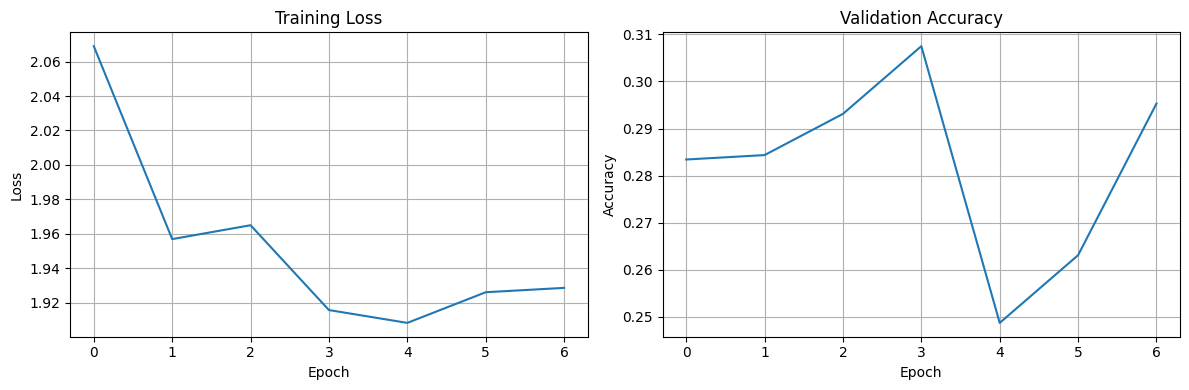

Total Parameters: 1,707,274
Total Training Time (s): 17.51
Average Time per Epoch (s): 2.50
Best Validation Accuracy (%): 30.75
Speedup factor (CPU avg / GPU avg): 2.23


In [16]:
import torch
import torch.nn as nn
import time

torch.manual_seed(2025)

device = torch.device("cuda")
print("Using device:", device, "| GPU:", torch.cuda.get_device_name(0))

class MLP(nn.Module):
    def __init__(self, h1=512, h2=256):
        super().__init__()
        self.fc1 = nn.Linear(3072, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = torch.flatten(x, 1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def val_acc(model, loader, max_batches=50):
    model.eval()
    correct = total = 0
    for i, (x, y) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.numel()
        if i + 1 >= max_batches:
            break
    return correct / total

def train_task2(train_loader, val_loader,
                max_epochs=20, patience=3, lr=0.05,
                max_batches_per_epoch=200, val_max_batches=50):

    model = MLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_accs, epoch_times = [], [], []
    best_acc, best_state, bad = -1.0, None, 0

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        model.train()

        total_loss = 0.0
        total_samples = 0

        for b, (x, y) in enumerate(train_loader, start=1):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            if b >= max_batches_per_epoch:
                break

        train_loss = total_loss / total_samples
        acc = val_acc(model, val_loader, max_batches=val_max_batches)

        train_losses.append(train_loss)
        val_accs.append(acc)
        epoch_times.append(time.time() - epoch_start)

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                break

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_accs, total_time, avg_epoch_time

model_gpu, train_losses_gpu, val_accs_gpu, total_time_gpu, avg_epoch_time_gpu = train_task2(train_loader, val_loader)

plot_training_curves(train_losses_gpu, val_accs_gpu)

print(f"Total Parameters: {count_params(model_gpu):,}")
print(f"Total Training Time (s): {total_time_gpu:.2f}")
print(f"Average Time per Epoch (s): {avg_epoch_time_gpu:.2f}")
print(f"Best Validation Accuracy (%): {max(val_accs_gpu)*100:.2f}")

cpu_avg_epoch_time = 5.57
print(f"Speedup factor (CPU avg / GPU avg): {cpu_avg_epoch_time / avg_epoch_time_gpu:.2f}")


*Task 2: Report speedup factor here*

| Metric | Value |
|--------|-------|
| **CPU Average Time per Epoch (seconds)** |5.57 |
| **GPU Average Time per Epoch (seconds)** |2.28|
| **Speedup Factor** | 2.44|

## Task 3

In this task you will show that a Convolutional Neural Network can use fewer parameters to train a better model. CNNs often achieve better performance with fewer parameters for computer vision tasks due to parameter sharing and translation invariance.

**1. Define a convolutional neural network [using PyTorch](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)** to classify the CIFAR-10 images. Your architecture should:
  - Contain at least one [convolutional layer](https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html) followed by nonlinear activations such as the [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) (you can use a deeper model with additional hidden layers but are not required to do so). 
      - You should experiment with different numbers of filters / out channels and kernel sizes, but common values include 8-32 channels and 3x3, 5x5, or 7x7 kernels. 
  - Contain at least one [pooling layer](https://pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html) (you can use a deeper model with additional hidden layers but are not required to do so)
      - You should experiment with different kernel sizes, but common values include 2x2 or 3x3
  - [Flatten](https://docs.pytorch.org/docs/stable/generated/torch.flatten.html) the output from the convolutional and pooling layers to vectors
  - Contain at least two [linear layers](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) (i.e., at least one hidden layer plus one output layer). The basic structure is: **input → conv → hidden → output**. You can use a deeper model with additional hidden layers but are not required to do so.
  - Use nonlinear activations ([ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) recommended) for hidden layers
  - Have 10 output units for the classification task
  - **Use fewer total model parameters than the MLP you used in Tasks 1-2.** The goal is to demonstrate that CNNs can achieve better performance with fewer parameters.
  - Note that the `test_loader` should not be used in this task.

**2. Train your model** as in Task 1, utilizing GPU compute as in Task 2. You could reuse your training function from Task 1.
    
**Your goal is to achieve a validation accuracy of 60% or better using fewer total model parameters than your MLP from Tasks 1-2.**

Once you reach this goal, **report the following:**
  - Use the `plot_training_curves` function to visualize the training results
  - Report the total number of model parameters. Show your work for the number of model parameters, either by showing your calculations or showing the code you used to count the number of model parameters ([The .parameters() method will return an iterable over the model parameters](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.parameters)).
  - Report the total amount of time that was required to train your model in seconds.
  - Report the average time per epoch in seconds.

Using device: cuda | GPU: Tesla T4
Epoch 1 | Train Loss: 1.9629 | Val Acc: 42.69%
Epoch 2 | Train Loss: 1.4619 | Val Acc: 51.38%
Epoch 3 | Train Loss: 1.2431 | Val Acc: 59.94%
Epoch 4 | Train Loss: 1.0732 | Val Acc: 63.28%
Epoch 5 | Train Loss: 0.9417 | Val Acc: 66.38%
Epoch 6 | Train Loss: 0.8256 | Val Acc: 67.50%
Epoch 7 | Train Loss: 0.7341 | Val Acc: 68.88%
Epoch 8 | Train Loss: 0.6309 | Val Acc: 70.53%
Epoch 9 | Train Loss: 0.5605 | Val Acc: 70.62%
Epoch 10 | Train Loss: 0.4724 | Val Acc: 70.66%
Epoch 11 | Train Loss: 0.3996 | Val Acc: 71.22%
Epoch 12 | Train Loss: 0.3301 | Val Acc: 70.22%
Epoch 13 | Train Loss: 0.2743 | Val Acc: 69.12%
Epoch 14 | Train Loss: 0.2289 | Val Acc: 71.84%
Epoch 15 | Train Loss: 0.1851 | Val Acc: 71.94%
Epoch 16 | Train Loss: 0.1478 | Val Acc: 72.09%
Epoch 17 | Train Loss: 0.1243 | Val Acc: 71.97%
Epoch 18 | Train Loss: 0.1065 | Val Acc: 70.91%
Epoch 19 | Train Loss: 0.1004 | Val Acc: 71.25%


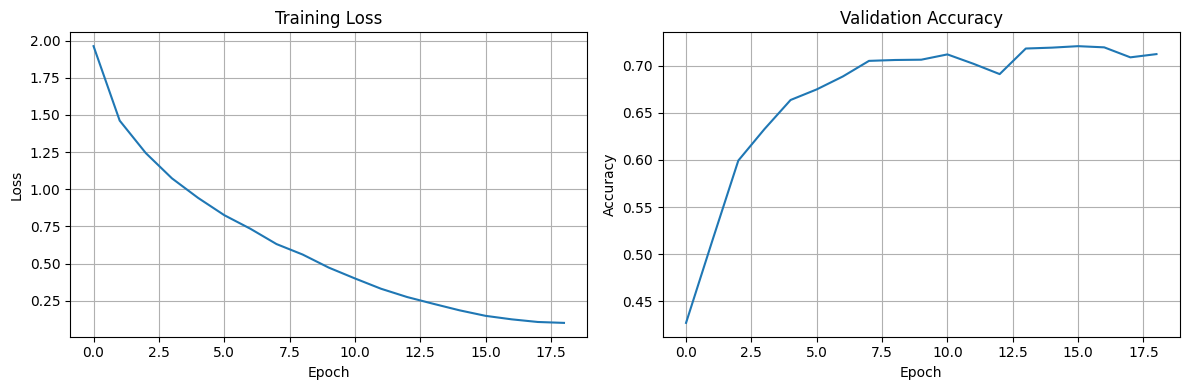

Total Parameters: 620,362
Total Training Time (s): 152.44
Average Time per Epoch (s): 8.02
Best Validation Accuracy (%): 72.09


In [10]:
# Write code for task 3 here

import torch
import torch.nn as nn
import time

torch.manual_seed(2025)

device = torch.device("cuda")
print("Using device:", device, "| GPU:", torch.cuda.get_device_name(0))

class ConvNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

def count_params(model):
    return sum(p.numel() for p in model.parameters())

@torch.no_grad()
def val_acc(model, loader, max_batches=50):
    model.eval()
    correct = total = 0
    for i, (x, y) in enumerate(loader):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.numel()
        if i + 1 >= max_batches:
            break
    return correct / total

def train_task3(train_loader, val_loader,
                max_epochs=20,
                patience=3,
                lr=0.01,
                max_batches_per_epoch=None):

    model = ConvNN().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    loss_fn = nn.CrossEntropyLoss()

    train_losses = []
    val_accs = []
    epoch_times = []

    best_acc = -1.0
    best_state = None
    bad_epochs = 0

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        model.train()

        total_loss = 0.0
        total_samples = 0

        for batch_idx, (x, y) in enumerate(train_loader, start=1):
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

            if max_batches_per_epoch is not None and batch_idx >= max_batches_per_epoch:
                break

        train_loss = total_loss / total_samples
        acc = val_acc(model, val_loader)

        train_losses.append(train_loss)
        val_accs.append(acc)
        epoch_times.append(time.time() - epoch_start)

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_accs, total_time, avg_epoch_time

model_cnn, train_losses_cnn, val_accs_cnn, total_time_cnn, avg_epoch_time_cnn = train_task3(
    train_loader, val_loader,
    max_epochs=25,
    patience=3,
    lr=0.01
)

plot_training_curves(train_losses_cnn, val_accs_cnn)

print(f"Total Parameters: {count_params(model_cnn):,}")
print(f"Total Training Time (s): {total_time_cnn:.2f}")
print(f"Average Time per Epoch (s): {avg_epoch_time_cnn:.2f}")
print(f"Best Validation Accuracy (%): {max(val_accs_cnn)*100:.2f}")


*For Task 3: report the number of model parameters, show work, and report training time here*

| Metric | Value |
|--------|-------|
| **CNN Total Parameters** |620,362 |
| **MLP Total Parameters (from Task 1)** |1,707,274 |
| **Work/Code Used** | sum(p.numel() for p in model.parameters())|
| **Total Training Time (seconds)** | 152.44|
| **Average Time per Epoch (seconds)** | 8.02|

## Task 4

In this task you will use dropout regularization during training to improve the generalization of your convolutional neural network.

1. Before adding dropout, let's establish a baseline. Take your best model from Task 3 (the one that achieved the highest validation accuracy) and evaluate its performance on the `test_loader` (which has not been used until now), to obtain the test accuracy **without Dropout**. Report this test accuracy.

2. Second, modify your convolutional neural network architecture that you defined in Task 3 to **use Dropout to improve generalization.** Specifically, add a [PyTorch Dropout layer](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html) after the hidden linear layer that comes right before the output layer with a drop rate `p = 0.2` (this is lower than the default). Then train the model exactly as you did in Task 3.

3. Finally, evaluate the the model of Step 2 with `test_loader` and report the test accuracy. Then report the accuracy difference before and after applying Dropout.

**Note:** It is possible you will not see an improvement in generalization performance when incorporating dropout, especially if your convolutional network from task 3 was not overfitting (e.g., a small network may actually underfit on the data). You **will not be penalized** as long as you have a correct implementation.

In [13]:
import torch
import torch.nn as nn
import time

torch.manual_seed(2025)

device = torch.device("cuda")
print("Using device:", device, "| GPU:", torch.cuda.get_device_name(0))

@torch.no_grad()
def accuracy(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        preds = model(x).argmax(1)
        correct += (preds == y).sum().item()
        total += y.numel()
    return correct / total

def count_params(model):
    return sum(p.numel() for p in model.parameters())

class ConvNN_NoDropout(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

class ConvNN_Dropout(nn.Module):
    def __init__(self, num_classes=10, p=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

def train_cnn(model, train_loader, val_loader,
              max_epochs=25, patience=3, lr=0.01):
    model = model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    loss_fn = nn.CrossEntropyLoss()

    train_losses, val_accs, epoch_times = [], [], []
    best_acc, best_state, bad_epochs = -1.0, None, 0

    start_time = time.time()
    for epoch in range(1, max_epochs + 1):
        epoch_start = time.time()
        model.train()

        total_loss = 0.0
        total_samples = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            optimizer.step()

            bs = y.size(0)
            total_loss += loss.item() * bs
            total_samples += bs

        train_loss = total_loss / total_samples
        val = accuracy(model, val_loader)

        train_losses.append(train_loss)
        val_accs.append(val)
        epoch_times.append(time.time() - epoch_start)

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val Acc: {val*100:.2f}%")

        if val > best_acc:
            best_acc = val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, train_losses, val_accs, total_time, avg_epoch_time


# 1) Baseline test accuracy (no dropout) using your best Task 3 model weights
# If you already have model_cnn from Task 3 trained, use it directly:
test_acc_no_dropout = accuracy(model_cnn.to(device), test_loader)
print(f"Test Accuracy (No Dropout): {test_acc_no_dropout*100:.2f}%")

# 2) Train dropout model
model_dropout, train_losses_do, val_accs_do, total_time_do, avg_epoch_time_do = train_cnn(
    ConvNN_Dropout(p=0.2),
    train_loader, val_loader,
    max_epochs=25, patience=3, lr=0.01
)

plot_training_curves(train_losses_do, val_accs_do)

# 3) Dropout test accuracy + difference
test_acc_dropout = accuracy(model_dropout.to(device), test_loader)
print(f"Test Accuracy (Dropout p=0.2): {test_acc_dropout*100:.2f}%")
print(f"Accuracy Difference (Dropout - NoDropout): {(test_acc_dropout - test_acc_no_dropout)*100:.2f}%")

print(f"Dropout Model Parameters: {count_params(model_dropout):,}")
print(f"Dropout Training Time (s): {total_time_do:.2f}")
print(f"Dropout Avg Time per Epoch (s): {avg_epoch_time_do:.2f}")


Using device: cuda | GPU: Tesla T4
Test Accuracy (No Dropout): 71.40%


KeyboardInterrupt: 

*For Task 4: Report **test accuracies** with and without dropout, and provide the test accuracy difference here.*

| Metric | Value |
|--------|-------|
| **Test Accuracy WITHOUT Dropout** | 71.40%|
| **Test Accuracy WITH Dropout** |73.48 |
| **Accuracy Difference** |2.08% |